<a href="https://colab.research.google.com/github/kartikay1725/ml_projects/blob/main/HOUSINGPRICE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shree1992/housedata")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'housedata' dataset.
Path to dataset files: /kaggle/input/housedata


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("housedata/data.csv")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [7]:
df.isnull().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


In [8]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [23]:
df.nunique()

,0
date,70
price,1741
bedrooms,10
bathrooms,26
sqft_living,566
sqft_lot,3113
floors,6
waterfront,2
view,5
condition,5


In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df[["date", "street", "city", "statezip", "country"]] = df[["date", "street", "city", "statezip", "country"]].apply(encoder.fit_transform)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled , columns = df.columns)
df_scaled.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,-1.833713,-0.423864,-0.441122,-0.843204,-0.829971,-0.193434,-0.022416,-0.085004,-0.309194,-0.667112,-0.565224,-0.672464,-0.531014,1.221670,-0.568577,0.861805,1.111825,0.0
1,-1.833713,3.249598,1.759705,0.432802,1.568528,-0.161718,0.906555,-0.085004,4.830079,2.286416,1.789559,-0.069128,-1.674693,-0.825693,1.249466,0.778343,0.920595,0.0
2,-1.833713,-0.372424,-0.441122,-0.205201,-0.217367,-0.080978,-0.951388,-0.085004,-0.309194,0.809652,0.119171,-0.672464,-0.161000,-0.825693,0.019591,-0.640521,-0.609244,0.0
3,-1.833713,-0.234071,-0.441122,0.113800,-0.144686,-0.190145,-0.951388,-0.085004,-0.309194,0.809652,-0.959621,1.482306,-0.261913,-0.825693,1.527871,-1.892459,-1.517585,0.0
4,-1.833713,-0.003482,0.659291,0.432802,-0.206984,-0.121306,-0.951388,-0.085004,-0.309194,0.809652,-0.797222,1.051352,0.175376,1.208396,1.595942,0.444493,-0.370206,0.0


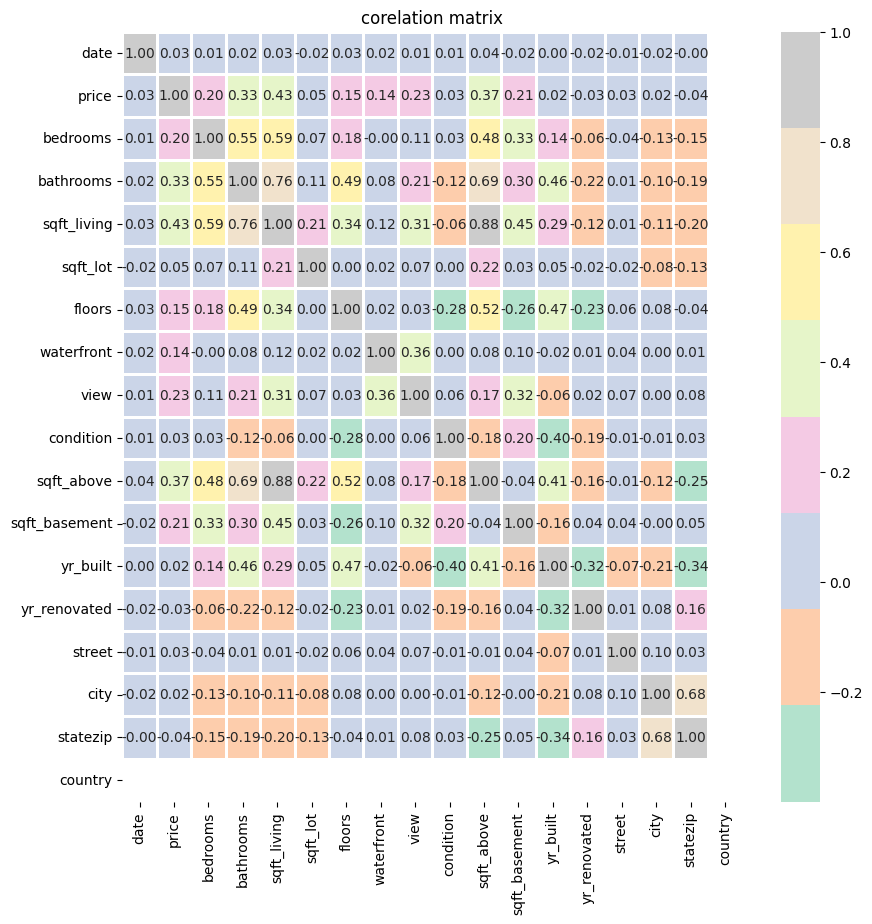

In [30]:
corr = df_scaled.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr , annot = True , fmt = ".2f" , cmap = 'Pastel2' , linewidths=2)
plt.title( "corelation matrix")
plt.show()

In [34]:
x = df_scaled[[ 'bedrooms', 'bathrooms', 'sqft_living',
       'floors', 'waterfront', 'view', 'sqft_above',
       'sqft_basement']]

y= df_scaled["price"]

In [35]:
x.head()  , y.head()

(   bedrooms  bathrooms  sqft_living  ...      view  sqft_above  sqft_basement
 0 -0.441122  -0.843204    -0.829971  ... -0.309194   -0.565224      -0.672464
 1  1.759705   0.432802     1.568528  ...  4.830079    1.789559      -0.069128
 2 -0.441122  -0.205201    -0.217367  ... -0.309194    0.119171      -0.672464
 3 -0.441122   0.113800    -0.144686  ... -0.309194   -0.959621       1.482306
 4  0.659291   0.432802    -0.206984  ... -0.309194   -0.797222       1.051352
 
 [5 rows x 8 columns],
 0   -0.423864
 1    3.249598
 2   -0.372424
 3   -0.234071
 4   -0.003482
 Name: price, dtype: float64)

In [39]:

from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.3 , random_state=42)
x_train , y_train , x_test, y_test

(      bedrooms  bathrooms  sqft_living  ...      view  sqft_above  sqft_basement
 2194  2.860118  -0.843204    -0.217367  ... -0.309194   -0.924821       1.266829
 958  -1.541536   0.113800    -0.944185  ... -0.309194   -1.006021      -0.090676
 1533 -0.441122  -0.843204    -0.694991  ... -0.309194   -0.414425      -0.672464
 654   0.659291   0.432802     0.582132  ... -0.309194    1.012365      -0.672464
 1497 -1.541536  -1.481206    -1.452958  ... -0.309194   -1.261219      -0.672464
 ...        ...        ...          ...  ...       ...         ...            ...
 4426 -0.441122  -1.481206    -0.996101  ... -0.309194   -0.750822      -0.672464
 466   0.659291  -0.205201     0.395236  ... -0.309194   -0.495624       1.740878
 3092 -0.441122  -1.481206    -1.027250  ... -0.309194   -0.971221      -0.327701
 3772 -1.541536  -1.481206    -1.276445  ... -0.309194   -1.064020      -0.672464
 860  -1.541536  -1.481206    -0.674224  ... -0.309194   -1.122020       0.685041
 
 [3220 rows x 

In [50]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score , classification_report

model = LinearRegression()
model.fit(x_train , y_train)

LinearRegression()

In [51]:
y_pred = model.predict(x_test)

In [52]:
mean_squared_error(y_test , y_pred)


2.1493892635243568

In [53]:
r2_score(y_test , y_pred)

0.05438300421190878

In [57]:
y_test.head()

,price
3683,-0.014124
4411,-0.979051
2584,2.058517
69,-0.331628
1844,-0.491266


In [59]:
y_pred

array([-0.31787446, -0.28475442,  0.76795113, ..., -0.3400291 ,
       -0.22255574, -0.15012909])

In [67]:
# Get the index of the 'price' column
price_col_index = df.columns.get_loc('price')

# Get the original mean and standard deviation for the 'price' column from the fitted scaler
original_price_mean = scaler.mean_[price_col_index]
original_price_std = scaler.scale_[price_col_index]

# Inverse transform the predicted scaled prices back to original dollar amounts
y_pred_dollars = (y_pred * original_price_std) + original_price_mean

print("First 5 predicted prices in original dollar scale:")
print(y_pred_dollars[:5])

First 5 predicted prices in original dollar scale:
[372753.82188926 391426.01743467 984913.41770487 552803.36238263
 420999.40615747]


In [88]:
x_indi =[[ 8, 2, 130,
       2, 0, 5, 100,
       1000]]
x_indi = scaler.fit_transform(x_indi)
y_indi = model.predict(x_indi)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [89]:
y_indi

array([-0.0109646])

In [90]:
# Get the index of the 'price' column
price_col_index = df.columns.get_loc('price')

# Get the original mean and standard deviation for the 'price' column from the fitted scaler
original_price_mean = scaler.mean_[price_col_index]
original_price_std = scaler.scale_[price_col_index]

# Inverse transform the predicted scaled prices back to original dollar amounts
y_pred_dollars = (y_indi * original_price_std) + original_price_mean

print("First 5 predicted prices in original dollar scale:")
print(y_pred_dollars[:5])

First 5 predicted prices in original dollar scale:
[1.9890354]


In [93]:
# --------------------------------------------
# HOUSE PRICE PREDICTION - COMPLETE PROJECT
# --------------------------------------------

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# -------------------------
# 1. Load Dataset
# -------------------------

df = pd.read_csv("housedata/output.csv")   # put your file name here

print("Dataset Shape:", df.shape)
print(df.head())

# -------------------------
# 2. Basic Cleaning
# -------------------------

# Fill missing numerical values with median
num_cols = ['bedrooms','bathrooms','sqft_living','sqft_lot','floors',
            'waterfront','view','condition','sqft_above','sqft_basement',
            'yr_built','yr_renovated']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values with mode
cat_cols = ['date','street','city','statezip','country']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# -------------------------
# 3. Feature Engineering
# -------------------------

# Convert date into useful features (Year, Month)
df['date'] = pd.to_datetime(df['date'])
df['year_sold'] = df['date'].dt.year
df['month_sold'] = df['date'].dt.month
df.drop('date', axis=1, inplace=True)

# -------------------------
# 4. Encode Categorical Variables
# -------------------------

label_enc = LabelEncoder()

for col in ['street', 'city', 'statezip', 'country']:
    df[col] = label_enc.fit_transform(df[col])

# -------------------------
# 5. Train-Test Split
# -------------------------

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# 6. Train Model
# -------------------------

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=15,
    min_samples_split=5
)

model.fit(X_train, y_train)

# -------------------------
# 7. Predictions & Evaluation
# -------------------------

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n📊 MODEL RESULTS:")
print("RMSE:", rmse)
print("R² Score:", r2)

# -------------------------
# 8. Predict on New Data
# -------------------------

sample = X_test.iloc[0:1]
predicted_price = model.predict(sample)

print("\nSample Input:\n", sample)
print("\nPredicted Price:", predicted_price[0])


Dataset Shape: (4600, 18)
                  date      price  bedrooms  ...       city  statezip  country
0  2014-05-02 00:00:00   313000.0       3.0  ...  Shoreline  WA 98133      USA
1  2014-05-02 00:00:00  2384000.0       5.0  ...    Seattle  WA 98119      USA
2  2014-05-02 00:00:00   342000.0       3.0  ...       Kent  WA 98042      USA
3  2014-05-02 00:00:00   420000.0       3.0  ...   Bellevue  WA 98008      USA
4  2014-05-02 00:00:00   550000.0       4.0  ...    Redmond  WA 98052      USA

[5 rows x 18 columns]

📊 MODEL RESULTS:
RMSE: 987613.8875467549
R² Score: 0.04359985172663272

Sample Input:
       bedrooms  bathrooms  sqft_living  ...  country  year_sold  month_sold
3683       3.0        2.5         1460  ...        0       2014           6

[1 rows x 18 columns]

Predicted Price: 435041.0018309653


In [94]:
import joblib
joblib.dump(model, 'model.pkl')

['model.pkl']